<a href="https://colab.research.google.com/github/EkaMiharja/SMOTE_LightGBM_V1/blob/hasil-1/SMOTELightBGM_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Import Library

In [61]:
# NumPy
# Digunakan untuk operasi numerik dan pengolahan array
import numpy as np

# Pandas
# Digunakan untuk membaca, mengolah, dan menganalisis dataset
import pandas as pd

# Matplotlib
# Digunakan untuk membuat visualisasi data
import matplotlib.pyplot as plt

# Seaborn
# Digunakan untuk membuat visualisasi statistik
import seaborn as sns

# Scikit-learn
# Digunakan untuk membagi dataset menjadi data training dan testing
from sklearn.model_selection import train_test_split

# Scikit-learn
# Digunakan untuk mengevaluasi performa model klasifikasi
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# LightGBM
# Digunakan untuk membuat dan melatih model Machine Learning untuk klasifikasi traffic jaringan
from lightgbm import LGBMClassifier

# Imbalanced-learn
# Digunakan untuk menangani ketidakseimbangan jumlah kelas pada dataset menggunakan metode SMOTE
from imblearn.over_sampling import SMOTE

## 2. Load Dataset

In [62]:
# Membaca dataset CIC-IDS2018 dari file CSV
df = pd.read_csv("/content/cic.csv")

# Menampilkan 5 baris pertama dataset
print(df.head())

# Menampilkan ukuran dataset
# Hasil: (jumlah baris, 80 kolom)
print("Ukuran dataset:", df.shape)

# Menampilkan jumlah kolom
print("Jumlah kolom:", len(df.columns))

# Menampilkan nama seluruh kolom
print("\nNama kolom:")
print(df.columns.tolist())

   Dst Port  Protocol            Timestamp  Flow Duration  Tot Fwd Pkts  \
0         0         0  14/02/2018 08:31:01      112641719             3   
1         0         0  14/02/2018 08:33:50      112641466             3   
2         0         0  14/02/2018 08:36:39      112638623             3   
3        22         6  14/02/2018 08:40:13        6453966            15   
4        22         6  14/02/2018 08:40:23        8804066            14   

   Tot Bwd Pkts  TotLen Fwd Pkts  TotLen Bwd Pkts  Fwd Pkt Len Max  \
0             0                0                0                0   
1             0                0                0                0   
2             0                0                0                0   
3            10             1239             2273              744   
4            11             1143             2209              744   

   Fwd Pkt Len Min  ...  Fwd Seg Size Min  Active Mean  Active Std  \
0                0  ...                 0          0.0    

## 3. Cleaning Dataset

# a.Melihat Informasi Dataset

In [63]:
# Digunakan untuk melihat jumlah data, nama kolom, dan tipe data setiap kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 80 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Dst Port           1048575 non-null  int64  
 1   Protocol           1048575 non-null  int64  
 2   Timestamp          1048575 non-null  object 
 3   Flow Duration      1048575 non-null  int64  
 4   Tot Fwd Pkts       1048575 non-null  int64  
 5   Tot Bwd Pkts       1048575 non-null  int64  
 6   TotLen Fwd Pkts    1048575 non-null  int64  
 7   TotLen Bwd Pkts    1048575 non-null  int64  
 8   Fwd Pkt Len Max    1048575 non-null  int64  
 9   Fwd Pkt Len Min    1048575 non-null  int64  
 10  Fwd Pkt Len Mean   1048575 non-null  float64
 11  Fwd Pkt Len Std    1048575 non-null  float64
 12  Bwd Pkt Len Max    1048575 non-null  int64  
 13  Bwd Pkt Len Min    1048575 non-null  int64  
 14  Bwd Pkt Len Mean   1048575 non-null  float64
 15  Bwd Pkt Len Std    1048575 non-n

# b.Mengecek missing value

In [64]:
# Digunakan untuk mengetahui apakah terdapat nilai kosong pada setiap kolom
print("\nJumlah Missing Value:")
print(df.isnull().sum())


Jumlah Missing Value:
Dst Port         0
Protocol         0
Timestamp        0
Flow Duration    0
Tot Fwd Pkts     0
                ..
Idle Mean        0
Idle Std         0
Idle Max         0
Idle Min         0
Label            0
Length: 80, dtype: int64


# c.Menghapus data duplikat

In [65]:
# Data yang sama tidak diperlukan untuk proses training
df = df.drop_duplicates()

print("\nUkuran dataset setelah menghapus duplikat:")
print(df.shape)


Ukuran dataset setelah menghapus duplikat:
(822947, 80)


# d.Mengecek nilai tak hingga

In [66]:
print("\nJumlah nilai Infinity:")
print(np.isinf(df.select_dtypes(include=np.number)).sum().sum())


Jumlah nilai Infinity:
5365


# e.Mengganti nilai Infinity menjadi NaN


In [67]:
df = df.replace([np.inf, -np.inf], np.nan)

# f.Mengecek kembali missing value


In [68]:
# Setelah nilai Infinity diubah menjadi NaN
print("\nMissing Value setelah pengecekan Infinity:")
print(df.isnull().sum().sum())


Missing Value setelah pengecekan Infinity:
7642


# g.Hapus missing value

In [69]:
# Dilakukan setelah Infinity diubah menjadi NaN
df = df.dropna()

print("\nUkuran dataset setelah membersihkan missing value:")
print(df.shape)


Ukuran dataset setelah membersihkan missing value:
(819126, 80)


# h.Mengecek kembali kondisi dataset


In [70]:
# untuk memastikan dataset sudah bersih
print("\nInformasi dataset setelah cleaning:")
df.info()


Informasi dataset setelah cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 819126 entries, 0 to 1048574
Data columns (total 80 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Dst Port           819126 non-null  int64  
 1   Protocol           819126 non-null  int64  
 2   Timestamp          819126 non-null  object 
 3   Flow Duration      819126 non-null  int64  
 4   Tot Fwd Pkts       819126 non-null  int64  
 5   Tot Bwd Pkts       819126 non-null  int64  
 6   TotLen Fwd Pkts    819126 non-null  int64  
 7   TotLen Bwd Pkts    819126 non-null  int64  
 8   Fwd Pkt Len Max    819126 non-null  int64  
 9   Fwd Pkt Len Min    819126 non-null  int64  
 10  Fwd Pkt Len Mean   819126 non-null  float64
 11  Fwd Pkt Len Std    819126 non-null  float64
 12  Bwd Pkt Len Max    819126 non-null  int64  
 13  Bwd Pkt Len Min    819126 non-null  int64  
 14  Bwd Pkt Len Mean   819126 non-null  float64
 15  Bwd Pkt Len Std   

## 4. EDA


# a.Melihat statistik deskriptif


In [71]:
# Digunakan untuk melihat nilai rata-rata, minimum,
# maksimum, dan statistik lainnya dari fitur numerik
print("Statistik Deskriptif:")
print(df.describe())

Statistik Deskriptif:
            Dst Port       Protocol  Flow Duration   Tot Fwd Pkts  \
count  819126.000000  819126.000000   8.191260e+05  819126.000000   
mean     6003.351760       8.697304   8.007824e+06       7.658836   
std     15799.742162       4.886142   1.425916e+09      50.228038   
min         0.000000       0.000000  -9.190110e+11       1.000000   
25%        53.000000       6.000000   3.170000e+02       1.000000   
50%        80.000000       6.000000   4.956450e+04       2.000000   
75%       445.000000      17.000000   1.755662e+06       9.000000   
max     65533.000000      17.000000   1.200000e+08    5115.000000   

        Tot Bwd Pkts  TotLen Fwd Pkts  TotLen Bwd Pkts  Fwd Pkt Len Max  \
count  819126.000000     8.191260e+05     8.191260e+05    819126.000000   
mean        8.957209     5.734126e+02     5.788421e+03       223.405172   
std       118.591371     1.780137e+04     1.713914e+05       308.277377   
min         0.000000     0.000000e+00     0.000000e+00  

# b.Melihat jumlah data pada setiap label

In [72]:
# Digunakan untuk mengetahui jenis traffic
# dan jumlah masing-masing kelas
print("\nDistribusi Label:")
print(df["Label"].value_counts())


Distribusi Label:
Label
Benign            662458
SSH-Bruteforce    117322
FTP-BruteForce     39346
Name: count, dtype: int64


# c.Melihat persentase setiap label


In [73]:
# Digunakan untuk mengetahui proporsi setiap kelas
print("\nPersentase Label:")
print(df["Label"].value_counts(normalize=True) * 100)


Persentase Label:
Label
Benign            80.873761
SSH-Bruteforce    14.322827
FTP-BruteForce     4.803412
Name: proportion, dtype: float64


# d.Visualisasi distribusi label


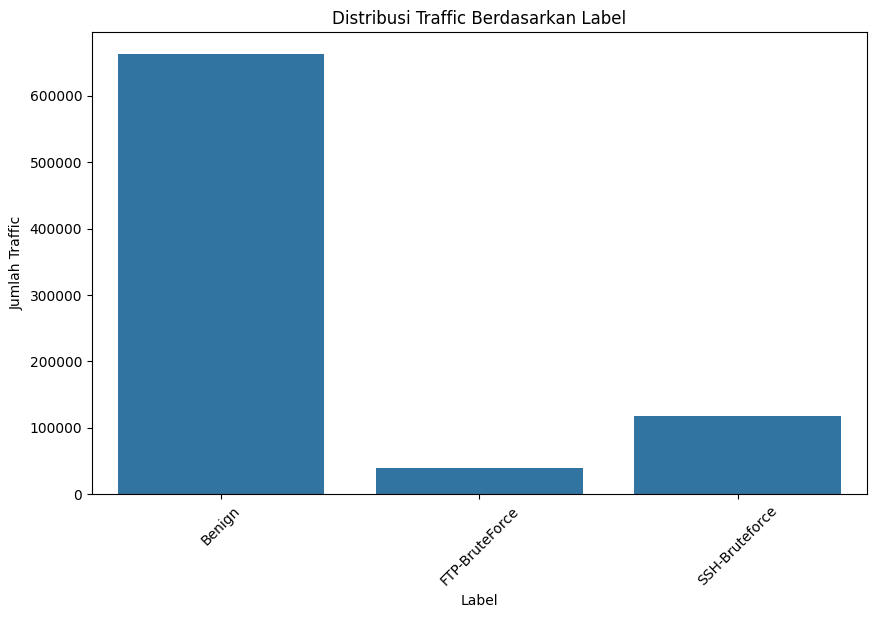

In [74]:
# Digunakan untuk melihat perbandingan jumlah
# traffic pada setiap kelas
plt.figure(figsize=(10, 6))

sns.countplot(data=df, x="Label")

plt.title("Distribusi Traffic Berdasarkan Label")
plt.xlabel("Label")
plt.ylabel("Jumlah Traffic")
plt.xticks(rotation=45)

plt.show()

# e.Melihat distribusi fitur numerik

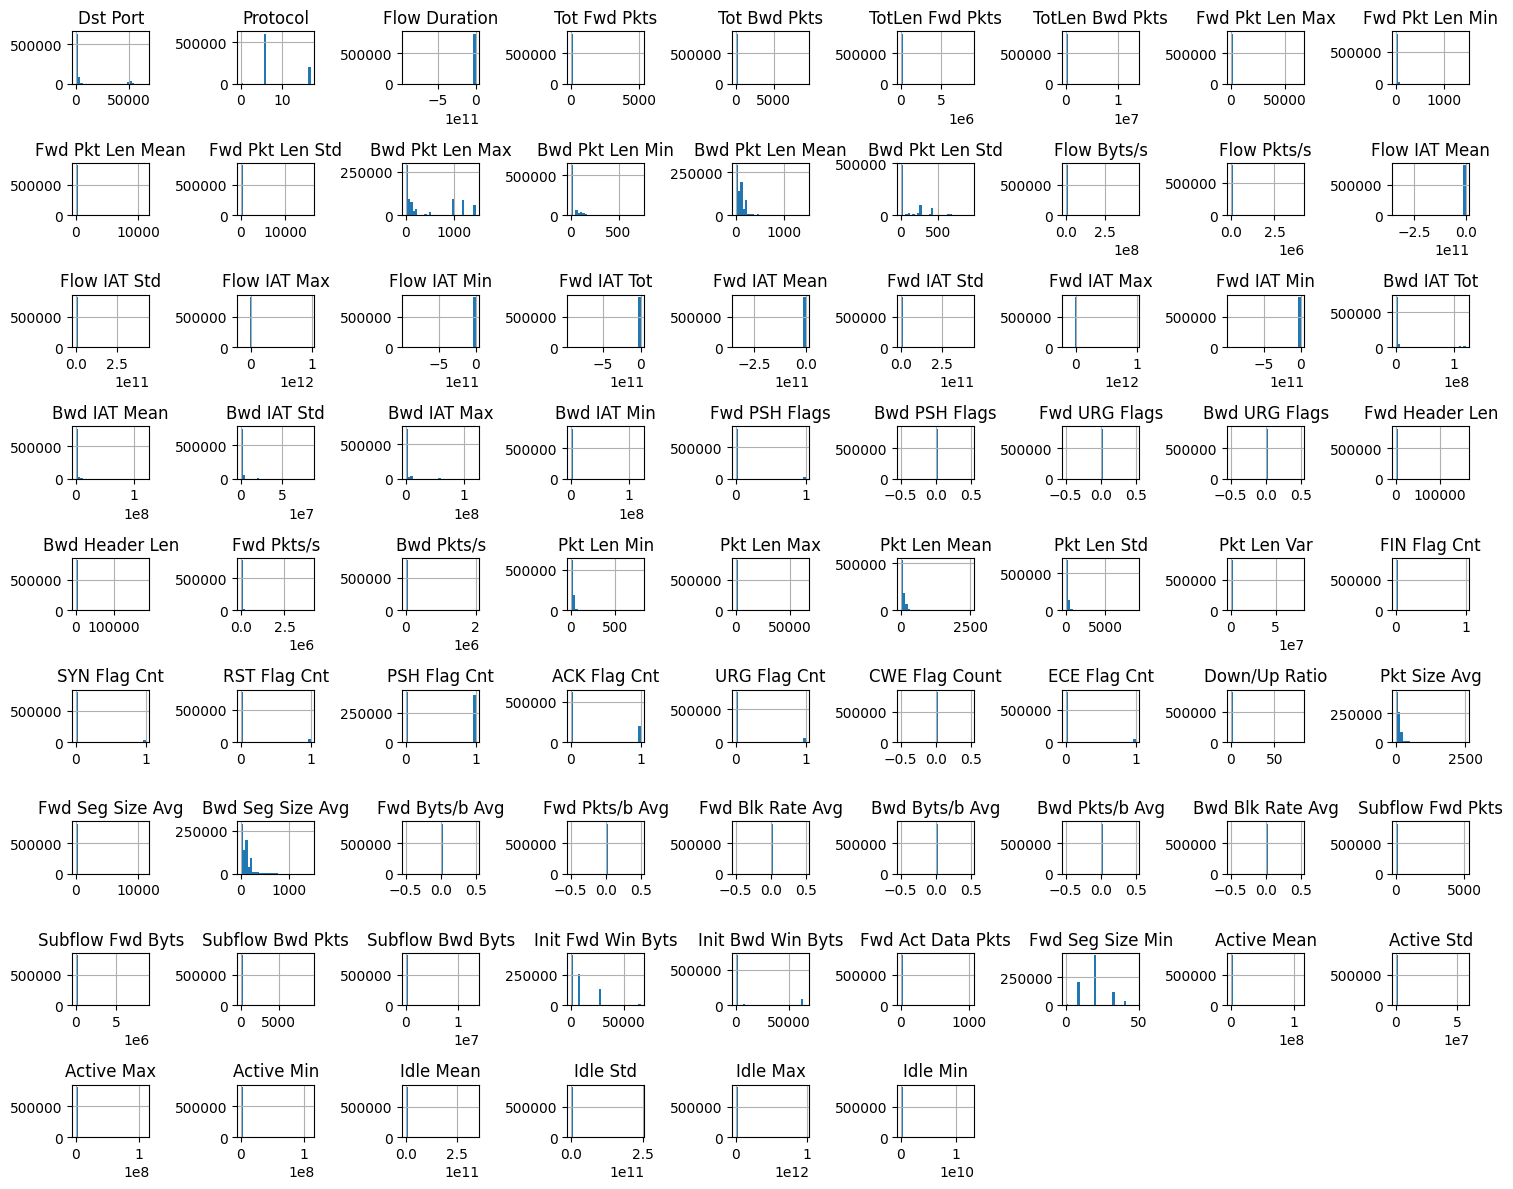

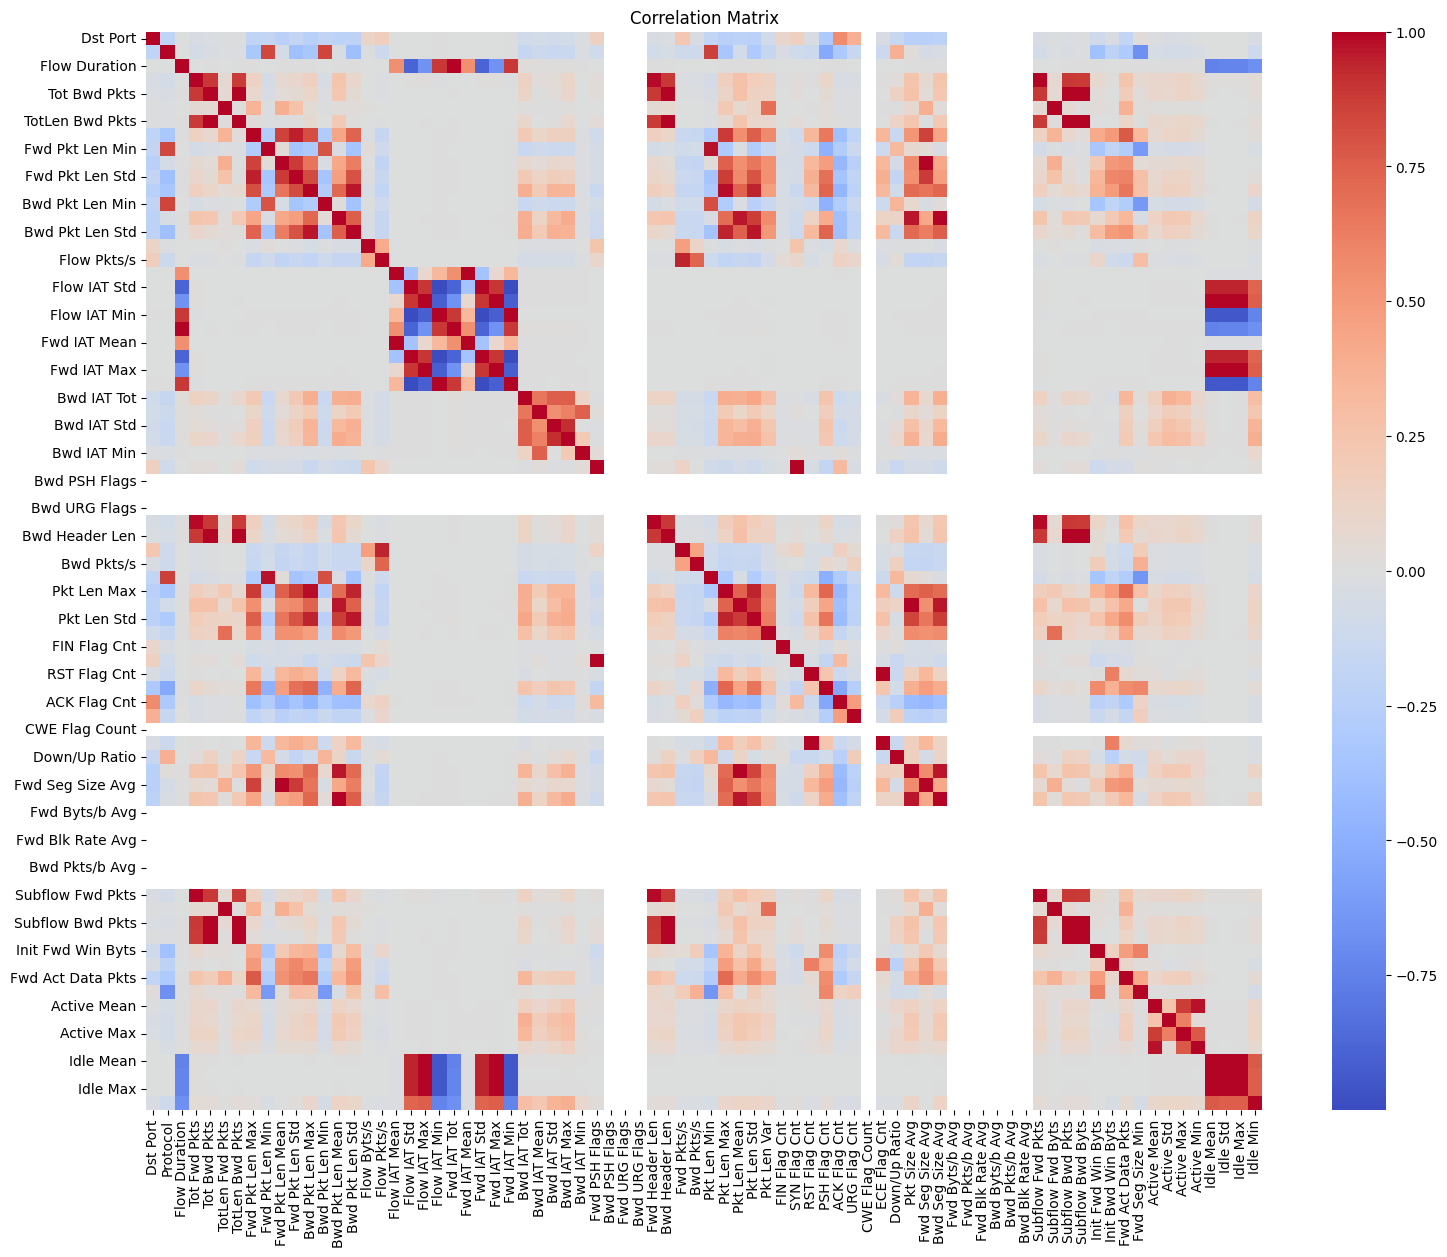

In [75]:
# Digunakan untuk mengetahui karakteristik
# beberapa fitur numerik dalam dataset
df.hist(figsize=(15, 12), bins=30)

plt.tight_layout()
plt.show()


# 4.6 Melihat korelasi antar fitur numerik
# Digunakan untuk mengetahui hubungan antar fitur
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

## 5. Menentukan Fitur dan  Target


# a.Melihat seluruh label yang tersedia


In [76]:
# Digunakan untuk mengetahui nama label pada dataset
print("Label yang tersedia:")
print(df["Label"].unique())

Label yang tersedia:
['Benign' 'FTP-BruteForce' 'SSH-Bruteforce']


# b.Menentukan label yang digunakan



In [77]:

# Normal dan Brute Force SSH
# dari df["Label"].unique()
target_labels = [
    "Benign",
    "SSH-Bruteforce"
]


# c.Mengambil data yang hanya memiliki label


In [78]:
# Normal dan Brute Force SSH
df_model = df[df["Label"].isin(target_labels)].copy()

# d.Mengecek kembali distribusi label

In [79]:
print("\nDistribusi label setelah filtering:")
print(df_model["Label"].value_counts())



Distribusi label setelah filtering:
Label
Benign            662458
SSH-Bruteforce    117322
Name: count, dtype: int64


# e.Menentukan target (y)


In [80]:
# Label merupakan target yang ingin diprediksi oleh model
y = df_model["Label"]

# f.Menentukan fitur (X)


In [81]:
# Timestamp dan Label tidak digunakan sebagai fitur
X = df_model.drop(columns=["Label", "Timestamp"])

# g.Melihat jumlah fitur yang digunakan


In [82]:
print("\nJumlah fitur:", X.shape[1])

# Melihat nama fitur
print("\nNama fitur:")
print(X.columns.tolist())


Jumlah fitur: 78

Nama fitur:
['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk 

## 6. Preprocessing

# a.Membersihkan nama kolom


In [83]:
# Menghilangkan spasi yang mungkin terdapat pada
# bagian awal atau akhir nama kolom
X.columns = X.columns.str.strip()

# b.Mengecek tipe data fitur


In [84]:
# Memastikan fitur dapat digunakan oleh model
print("Tipe data fitur:")
print(X.dtypes)

Tipe data fitur:
Dst Port           int64
Protocol           int64
Flow Duration      int64
Tot Fwd Pkts       int64
Tot Bwd Pkts       int64
                  ...   
Active Min         int64
Idle Mean        float64
Idle Std         float64
Idle Max           int64
Idle Min           int64
Length: 78, dtype: object


# c.Mengubah label menjadi angka


In [85]:
# Benign dan Brute Force SSH akan diubah menjadi
# nilai numerik agar dapat diproses oleh model
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

# d.Melihat hasil encoding label


In [86]:
print("\nMapping label:")
for label, encoded in zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
):
    print(f"{label} = {encoded}")


Mapping label:
Benign = 0
SSH-Bruteforce = 1


# e.Melihat bentuk akhir X dan y


In [87]:
print("\nUkuran X:", X.shape)
print("Ukuran y:", y.shape)


Ukuran X: (779780, 78)
Ukuran y: (779780,)


## 7. Train Test Split

# a.Membagi dataset menjadi data training dan testing

In [88]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# b.Menampilkan ukuran masing-masing data


In [89]:
print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test :", X_test.shape)
print("Ukuran y_train:", y_train.shape)
print("Ukuran y_test :", y_test.shape)

Ukuran X_train: (623824, 78)
Ukuran X_test : (155956, 78)
Ukuran y_train: (623824,)
Ukuran y_test : (155956,)


# c.Mengecek distribusi label pada data training

In [90]:

print("\nDistribusi label pada data training:")
print(pd.Series(y_train).value_counts())



Distribusi label pada data training:
0    529966
1     93858
Name: count, dtype: int64


# d.Mengecek distribusi label pada data testing


In [91]:
print("\nDistribusi label pada data testing:")
print(pd.Series(y_test).value_counts())


Distribusi label pada data testing:
0    132492
1     23464
Name: count, dtype: int64


## 8. Menangani Imbalanced data dengan SMOTE

# a.Melihat distribusi kelas sebelum SMOTE


In [92]:
print("Distribusi kelas sebelum SMOTE:")
print(pd.Series(y_train).value_counts())

Distribusi kelas sebelum SMOTE:
0    529966
1     93858
Name: count, dtype: int64


# b.Membuat objek SMOTE


In [93]:
# random_state digunakan agar hasil dapat direproduksi
smote = SMOTE(random_state=42)

# c.Melakukan SMOTE pada data training

In [94]:
# X_train dan y_train yang diproses
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# d.Melihat distribusi kelas setelah SMOTE

In [95]:
print("\nDistribusi kelas setelah SMOTE:")
print(pd.Series(y_train_smote).value_counts())



Distribusi kelas setelah SMOTE:
0    529966
1    529966
Name: count, dtype: int64


# e.Melihat ukuran data setelah SMOTE

In [96]:
print("\nUkuran X_train sebelum SMOTE:", X_train.shape)
print("Ukuran X_train setelah SMOTE:", X_train_smote.shape)

print("\nUkuran y_train sebelum SMOTE:", y_train.shape)
print("Ukuran y_train setelah SMOTE:", y_train_smote.shape)


Ukuran X_train sebelum SMOTE: (623824, 78)
Ukuran X_train setelah SMOTE: (1059932, 78)

Ukuran y_train sebelum SMOTE: (623824,)
Ukuran y_train setelah SMOTE: (1059932,)


## 9. Membuat Model LightGBM

# a.Membuat model LightGBM untuk klasifikasi

In [97]:
model_lgbm = LGBMClassifier(
    objective="binary",      # Klasifikasi 2 kelas
    n_estimators=100,        # Jumlah decision tree
    learning_rate=0.1,      # Kecepatan model dalam belajar
    max_depth=6,            # Kedalaman Tree
    random_state=42          # Agar hasil dapat direproduksi
)

In [98]:
# Menampilkan konfigurasi model
print(model_lgbm)

LGBMClassifier(max_depth=6, objective='binary', random_state=42)


## 10. Training Model

# a.Melatih model menggunakan data training


In [99]:
# sudah diseimbangkan dengan SMOTE
model_lgbm.fit(
    X_train_smote,
    y_train_smote
)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 529966, number of negative: 529966
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.326705 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13748
[LightGBM] [Info] Number of data points in the train set: 1059932, number of used features: 68
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

LGBMClassifier(max_depth=6, objective='binary', random_state=42)

## 11. Melihat Prediksi

# a. Melakukan Prediksi dan Dibandingkan dengan Label Sebenarnya

In [100]:
# Melakukan prediksi terhadap data testing
y_pred = model_lgbm.predict(X_test)

# Menampilkan beberapa hasil prediksi pertama
print("Hasil prediksi:")
print(y_pred[:20])

# Menampilkan label sebenarnya
print("\nLabel sebenarnya:")
print(y_test[:20])

Hasil prediksi:
[0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]

Label sebenarnya:
[0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]


## 12. Evaluasi Model

# a. Hitung Akurasi, Precision, dan F1-Score

In [101]:
# Menghitung Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Menghitung Precision
precision = precision_score(y_test, y_pred)

# Menghitung Recall
recall = recall_score(y_test, y_pred)

# Menghitung F1-Score
f1 = f1_score(y_test, y_pred)


In [102]:
# Menampilkan hasil evaluasi
print("Hasil Evaluasi Model LightGBM")
print("--------------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

Hasil Evaluasi Model LightGBM
--------------------------------
Accuracy  : 1.0000
Precision : 0.9999
Recall    : 1.0000
F1-Score  : 1.0000


In [103]:
# Menampilkan classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))


Classification Report:
                precision    recall  f1-score   support

        Benign       1.00      1.00      1.00    132492
SSH-Bruteforce       1.00      1.00      1.00     23464

      accuracy                           1.00    155956
     macro avg       1.00      1.00      1.00    155956
  weighted avg       1.00      1.00      1.00    155956



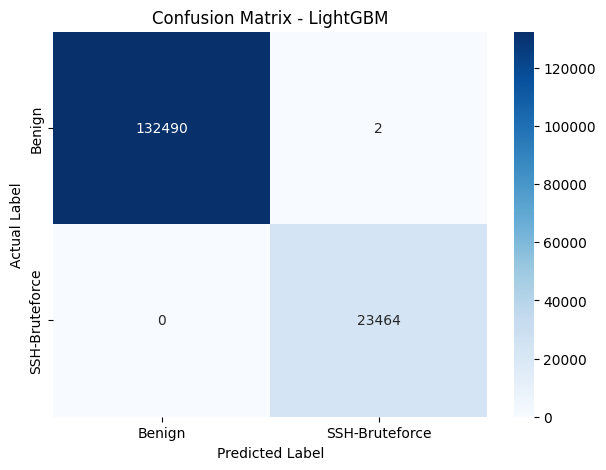

In [104]:
# CONFUSION MATRIX

# Membuat confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Menampilkan confusion matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - LightGBM")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

## 13. Feature Importance

# a.Mengambil nilai feature importance dari model LightGBM


In [105]:
importance = model_lgbm.feature_importances_


In [106]:
# Membuat DataFrame untuk menyimpan
# nama fitur dan nilai importance
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
})


In [107]:
# Mengurutkan fitur dari yang paling penting
# ke yang paling rendah
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# b.Menampilkan 20 Fitur Terpenting

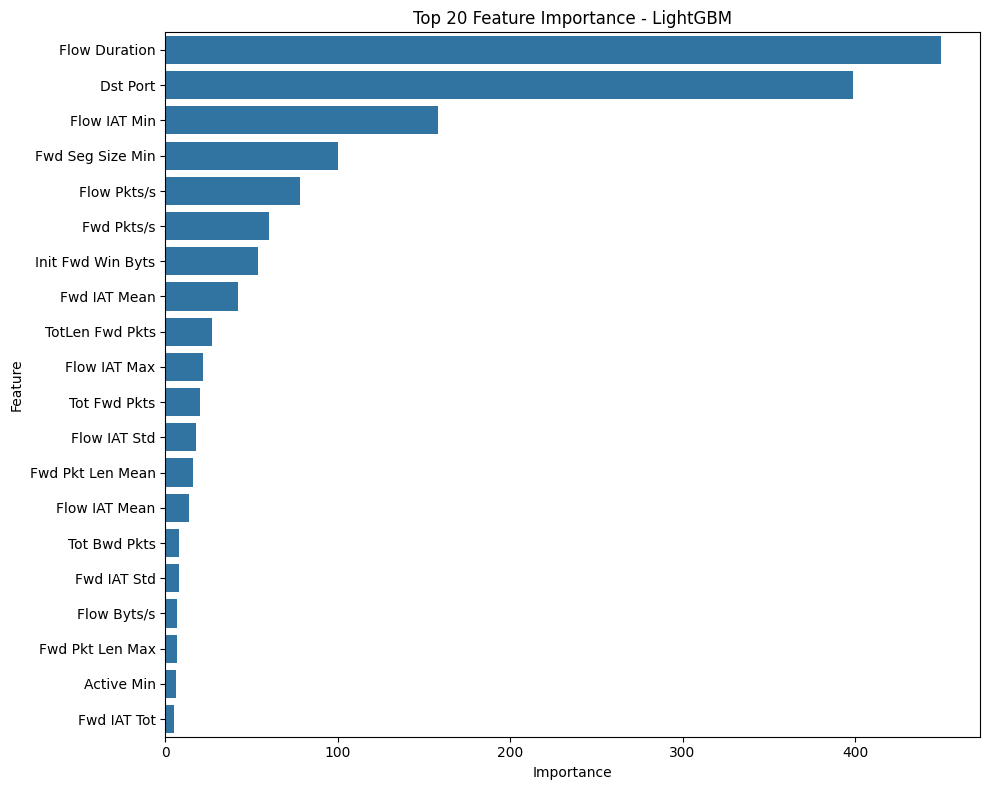

In [108]:
# Menampilkan 20 fitur paling penting
top_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Feature Importance - LightGBM")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 14. Feature Selection

# a.Menentukan jumlah fitur yang ingin digunakan

In [109]:
# Kita memilih 20 fitur dengan importance tertinggi
jumlah_fitur = 20

In [110]:
# Mengambil 20 fitur dengan importance tertinggi
selected_features = (
    feature_importance
    .head(jumlah_fitur)["Feature"]
    .tolist()
)


In [111]:
# Menampilkan fitur yang terpilih
print("Fitur yang dipilih:")
for i, feature in enumerate(selected_features, start=1):
    print(f"{i}. {feature}")


Fitur yang dipilih:
1. Flow Duration
2. Dst Port
3. Flow IAT Min
4. Fwd Seg Size Min
5. Flow Pkts/s
6. Fwd Pkts/s
7. Init Fwd Win Byts
8. Fwd IAT Mean
9. TotLen Fwd Pkts
10. Flow IAT Max
11. Tot Fwd Pkts
12. Flow IAT Std
13. Fwd Pkt Len Mean
14. Flow IAT Mean
15. Tot Bwd Pkts
16. Fwd IAT Std
17. Flow Byts/s
18. Fwd Pkt Len Max
19. Active Min
20. Fwd IAT Tot


# b.Membuat X baru hanya dengan fitur terpilih

In [112]:
X_selected = X[selected_features]


In [113]:
# Melihat ukuran dataset setelah feature selection
print("\nUkuran X sebelum feature selection:")
print(X.shape)

print("\nUkuran X setelah feature selection:")
print(X_selected.shape)


Ukuran X sebelum feature selection:
(779780, 78)

Ukuran X setelah feature selection:
(779780, 20)


# c.Membagi Dataset Dengan Fitur Terpilih

In [114]:
# Membagi dataset berdasarkan fitur yang sudah dipilih
X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(
    X_selected,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [115]:
# Menampilkan ukuran data
print("X_train_selected:", X_train_selected.shape)
print("X_test_selected :", X_test_selected.shape)

X_train_selected: (623824, 20)
X_test_selected : (155956, 20)


# d.SMOTE pada Fitur Terpilih

In [116]:
# Membuat objek SMOTE
smote_selected = SMOTE(random_state=42)


# SMOTE hanya pada data training
X_train_selected_smote, y_train_selected_smote = (
    smote_selected.fit_resample(
        X_train_selected,
        y_train_selected
    )
)


In [117]:
# Melihat ukuran setelah SMOTE
print("X_train sebelum SMOTE:", X_train_selected.shape)
print("X_train setelah SMOTE:", X_train_selected_smote.shape)

print("\ny_train sebelum SMOTE:", y_train_selected.shape)
print("y_train setelah SMOTE:", y_train_selected_smote.shape)

X_train sebelum SMOTE: (623824, 20)
X_train setelah SMOTE: (1059932, 20)

y_train sebelum SMOTE: (623824,)
y_train setelah SMOTE: (1059932,)


## 15. Training Ulang LightGBM

# a. Mmebuat Model LightGBM baru

In [118]:
# Membuat model LightGBM baru
model_lgbm_selected = LGBMClassifier(
    objective="binary",
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

In [119]:
# Melatih model menggunakan 20 fitur terpilih
model_lgbm_selected.fit(
    X_train_selected_smote,
    y_train_selected_smote
)


# Menampilkan informasi
print("Training LightGBM dengan 20 fitur selesai.")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 529966, number of negative: 529966
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.078975 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4792
[LightGBM] [Info] Number of data points in the train set: 1059932, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

## 16. Prediksi dan Evaluasi Model 20 Fitur

# a.Melakukan Prediksi

In [120]:
# Melakukan prediksi pada data testing
y_pred_selected = model_lgbm_selected.predict(X_test_selected)

# Menampilkan beberapa hasil prediksi
print("20 hasil prediksi pertama:")
print(y_pred_selected[:20])

print("\n20 label sebenarnya pertama:")
print(y_test_selected[:20])

20 hasil prediksi pertama:
[0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]

20 label sebenarnya pertama:
[0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]


# b.Evaluasi 20 Fitur


In [121]:
# Menghitung metrik evaluasi
accuracy_selected = accuracy_score(
    y_test_selected,
    y_pred_selected
)

precision_selected = precision_score(
    y_test_selected,
    y_pred_selected
)

recall_selected = recall_score(
    y_test_selected,
    y_pred_selected
)

f1_selected = f1_score(
    y_test_selected,
    y_pred_selected
)


# Menampilkan hasil evaluasi
print("Hasil Evaluasi Model LightGBM - 20 Fitur")
print("------------------------------------------")
print(f"Accuracy  : {accuracy_selected:.4f}")
print(f"Precision : {precision_selected:.4f}")
print(f"Recall    : {recall_selected:.4f}")
print(f"F1-Score  : {f1_selected:.4f}")

Hasil Evaluasi Model LightGBM - 20 Fitur
------------------------------------------
Accuracy  : 1.0000
Precision : 0.9999
Recall    : 1.0000
F1-Score  : 1.0000


# c. Confusion Matrix 20 Fitur

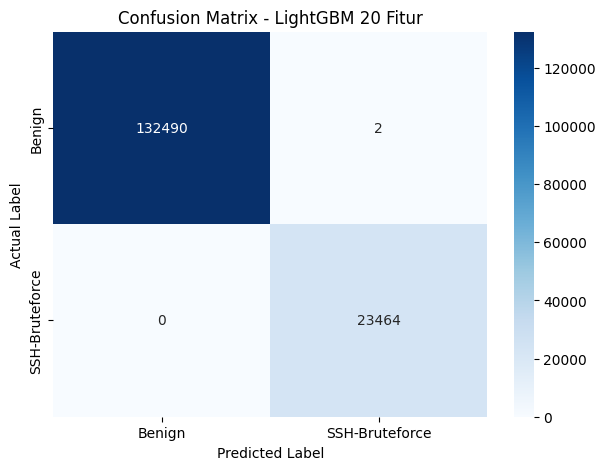

In [122]:
# Membuat confusion matrix
cm_selected = confusion_matrix(
    y_test_selected,
    y_pred_selected
)


# Membuat visualisasi
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_selected,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - LightGBM 20 Fitur")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

# d. Membandingkan Training dan Testing

In [123]:
# Prediksi pada data training
y_train_pred_selected = model_lgbm_selected.predict(
    X_train_selected
)

# Prediksi pada data testing
y_test_pred_selected = model_lgbm_selected.predict(
    X_test_selected
)

# Menghitung accuracy training
accuracy_train_selected = accuracy_score(
    y_train_selected,
    y_train_pred_selected
)

# Menghitung accuracy testing
accuracy_test_selected = accuracy_score(
    y_test_selected,
    y_test_pred_selected
)

print("Perbandingan Training dan Testing")
print("----------------------------------")
print(f"Training Accuracy : {accuracy_train_selected:.4f}")
print(f"Testing Accuracy  : {accuracy_test_selected:.4f}")

# Menghitung selisih accuracy
selisih_accuracy = (
    accuracy_train_selected -
    accuracy_test_selected
)

print(f"Selisih Accuracy   : {selisih_accuracy:.4f}")

Perbandingan Training dan Testing
----------------------------------
Training Accuracy : 1.0000
Testing Accuracy  : 1.0000
Selisih Accuracy   : 0.0000


## 17. Hyperparameter Tuning LightGBM

# a.Menentukan parameter yang akan diuji

In [131]:
lgbm_tuning = LGBMClassifier(
    objective="binary",
    random_state=42
)

# Parameter yang akan diuji
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [4, 6],
    "num_leaves": [15, 31]
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=lgbm_tuning,
    param_grid=param_grid,
    scoring="f1",
    cv=2,
    n_jobs=-1,
    verbose=1
)

# Training tuning
grid_search.fit(
    X_train_selected_smote,
    y_train_selected_smote
)

print("\nParameter terbaik:")
print(grid_search.best_params_)

print("\nF1-Score terbaik:")
print(grid_search.best_score_)

Fitting 2 folds for each of 16 candidates, totalling 32 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 529966, number of negative: 529966
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.125277 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4792
[LightGBM] [Info] Number of data points in the train set: 1059932, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

## 18. Training Model dengan Parameter Terbaik

# a.Training Model dengan Parameter Terbaik


In [132]:
model_lgbm_final = LGBMClassifier(
    objective="binary",
    learning_rate=0.05,
    max_depth=4,
    n_estimators=200,
    num_leaves=15,
    random_state=42
)

# Training menggunakan data training yang sudah SMOTE
model_lgbm_final.fit(
    X_train_selected_smote,
    y_train_selected_smote
)

print("Training model dengan parameter terbaik selesai.")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 529966, number of negative: 529966
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.080087 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4792
[LightGBM] [Info] Number of data points in the train set: 1059932, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

In [133]:
# Melakukan prediksi pada data testing
y_pred_final = model_lgbm_final.predict(
    X_test_selected
)

print("20 hasil prediksi pertama:")
print(y_pred_final[:20])

print("\n20 label sebenarnya pertama:")
print(y_test_selected[:20])

20 hasil prediksi pertama:
[0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]

20 label sebenarnya pertama:
[0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]


In [135]:
accuracy_final = accuracy_score(
    y_test_selected,
    y_pred_final
)

precision_final = precision_score(
    y_test_selected,
    y_pred_final
)

recall_final = recall_score(
    y_test_selected,
    y_pred_final
)

f1_final = f1_score(
    y_test_selected,
    y_pred_final
)

print("Hasil Evaluasi Model Final LightGBM")
print("------------------------------------")
print(f"Accuracy  : {accuracy_final:.4f}")
print(f"Precision : {precision_final:.4f}")
print(f"Recall    : {recall_final:.4f}")
print(f"F1-Score  : {f1_final:.4f}")

# ============================================
# CLASSIFICATION REPORT
# ============================================

print("\nClassification Report:")

print(
    classification_report(
        y_test_selected,
        y_pred_final,
        target_names=label_encoder.classes_
    )
)

Hasil Evaluasi Model Final LightGBM
------------------------------------
Accuracy  : 1.0000
Precision : 0.9999
Recall    : 1.0000
F1-Score  : 1.0000

Classification Report:
                precision    recall  f1-score   support

        Benign       1.00      1.00      1.00    132492
SSH-Bruteforce       1.00      1.00      1.00     23464

      accuracy                           1.00    155956
     macro avg       1.00      1.00      1.00    155956
  weighted avg       1.00      1.00      1.00    155956



# b.Confusion Matrix

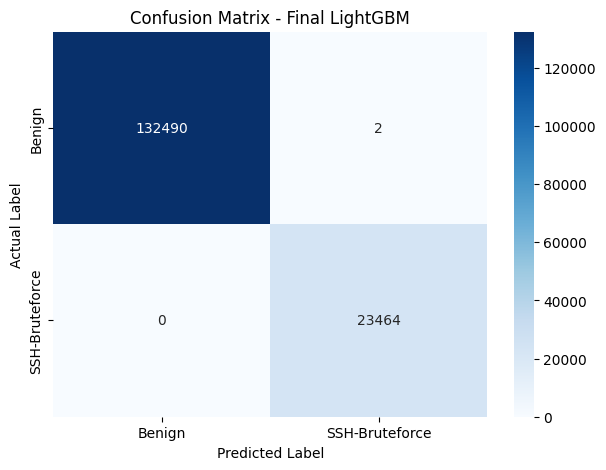

In [136]:


cm_final = confusion_matrix(
    y_test_selected,
    y_pred_final
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - Final LightGBM")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()


# c.Feature Importance Final

In [138]:
# Mengambil nilai feature importance
importance_final = model_lgbm_final.feature_importances_

# Membuat dataframe feature importance
feature_importance_final = pd.DataFrame({
    "Feature": X_train_selected.columns,
    "Importance": importance_final
})

# Mengurutkan dari fitur paling penting
feature_importance_final = feature_importance_final.sort_values(
    by="Importance",
    ascending=False
)

# Menampilkan seluruh 20 fitur
print("Feature Importance Model Final:")
print(feature_importance_final)

Feature Importance Model Final:
              Feature  Importance
0       Flow Duration         545
1            Dst Port         467
2        Flow IAT Min         245
3    Fwd Seg Size Min         200
6   Init Fwd Win Byts         134
5          Fwd Pkts/s          88
4         Flow Pkts/s          50
11       Flow IAT Std          29
9        Flow IAT Max          16
8     TotLen Fwd Pkts          13
10       Tot Fwd Pkts           9
7        Fwd IAT Mean           5
18         Active Min           5
12   Fwd Pkt Len Mean           4
13      Flow IAT Mean           4
14       Tot Bwd Pkts           3
19        Fwd IAT Tot           3
16        Flow Byts/s           2
15        Fwd IAT Std           1
17    Fwd Pkt Len Max           0


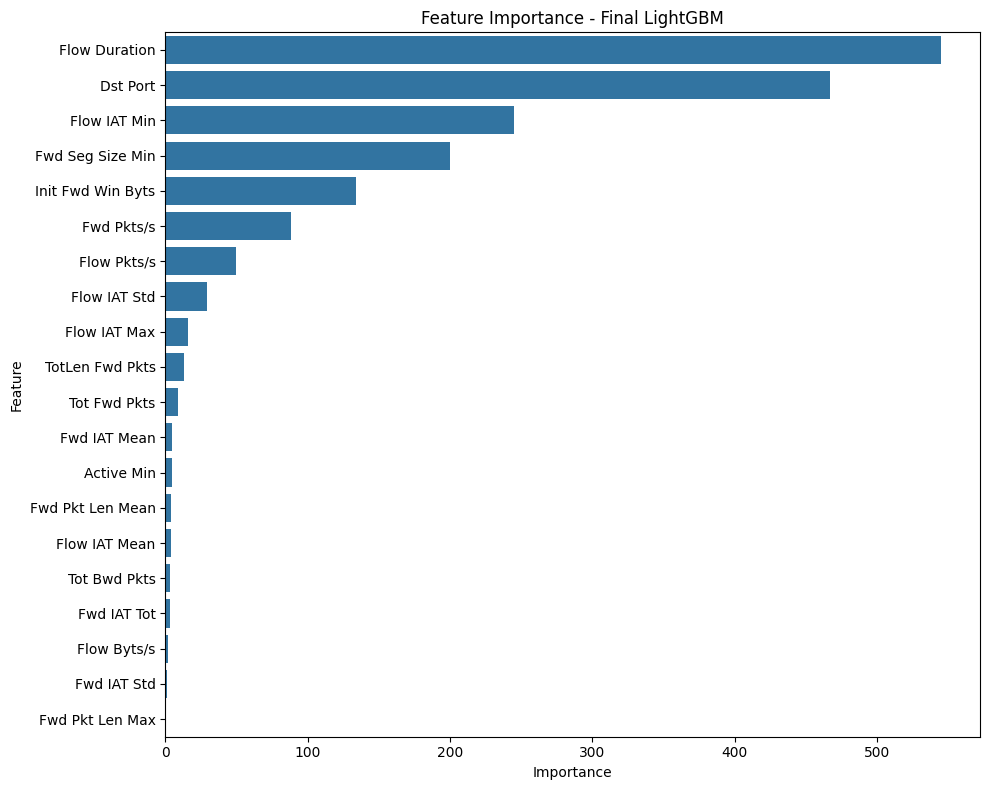

In [139]:
# VISUALISASI FEATURE IMPORTANCE

top_features_final = feature_importance_final.head(20)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_features_final,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Final LightGBM")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()